In [27]:
#Setup & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Load dataset
df = pd.read_csv("superstore.csv")

# Clean column names (remove # and spaces)
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("#", "")
)

print("Columns:", df.columns.tolist())
print(df.head())
print(df.info())
print(len(df))

Columns: ['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit']
   row_id        order_id order_date ship_date       ship_mode customer_id  \
0       1  CA-2016-152156    11/8/16  11/11/16    Second Class    CG-12520   
1       2  CA-2016-152156    11/8/16  11/11/16    Second Class    CG-12520   
2       3  CA-2016-138688    6/12/16   6/16/16    Second Class    DV-13045   
3       4  US-2015-108966   10/11/15  10/18/15  Standard Class    SO-20335   
4       5  US-2015-108966   10/11/15  10/18/15  Standard Class    SO-20335   

     customer_name    segment        country             city  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Lo

In [28]:
#Data Cleaning & Preprocessing
# Convert date columns
df['order_date'] = pd.to_datetime(df['order_date'], format='%m/%d/%y')
df['ship_date'] = pd.to_datetime(df['ship_date'], format='%m/%d/%y')

# Drop invalid rows
df = df.dropna(subset=['order_date', 'sales'])

# Fill missing categorical values
cat_cols = ['ship_mode','segment','country','city','state','region','category','sub_category','product_name']
for c in cat_cols:
    df[c] = df[c].fillna('Unknown')

# Fill missing numeric values
num_cols = ['sales','quantity','discount','profit']
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

# Remove duplicates
df = df.drop_duplicates()

print("After cleaning:", df.shape)

After cleaning: (9994, 21)


In [29]:
#Outlier Detection (IQR)
def remove_outliers_iqr(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return data[(data[col] >= lower) & (data[col] <= upper)]

df_no_outliers = df.copy()
df_no_outliers = remove_outliers_iqr(df_no_outliers, 'sales')
df_no_outliers = remove_outliers_iqr(df_no_outliers, 'profit')

print("After outlier handling:", df_no_outliers.shape)

After outlier handling: (7392, 21)


In [30]:
#Feature Engineering
df_no_outliers['year'] = df_no_outliers['order_date'].dt.year
df_no_outliers['month'] = df_no_outliers['order_date'].dt.month
df_no_outliers['month_name'] = df_no_outliers['order_date'].dt.month_name()
df_no_outliers['quarter'] = df_no_outliers['order_date'].dt.to_period('Q').astype(str)

df_no_outliers['profit_margin_pct'] = np.where(
    df_no_outliers['sales'] > 0,
    (df_no_outliers['profit'] / df_no_outliers['sales']) * 100,
    0
)

In [31]:
# KPI Computation
total_sales = df_no_outliers['sales'].sum()
total_profit = df_no_outliers['profit'].sum()

profit_margin_pct = round(
    (total_profit / total_sales) * 100, 2
) if total_sales not in [0, None] and not pd.isna(total_sales) else 0.0

kpis = {
    "total_sales": total_sales,
    "total_profit": total_profit,
    "profit_margin_pct": profit_margin_pct,
    "total_orders": df_no_outliers['order_id'].nunique(),
    "avg_order_value": df_no_outliers['sales'].mean()
}
kpis_df = pd.DataFrame([kpis])
print(kpis_df)

import os
os.makedirs("outputs", exist_ok=True)
kpis_df.to_csv("outputs/kpis.csv", index=False)

   total_sales  total_profit  profit_margin_pct  total_orders  avg_order_value
0  460629.5159    71229.6845              15.46          4281        62.314599


In [32]:
#BI Aggregations
monthly_sales = (
    df_no_outliers
    .groupby(pd.Grouper(key='order_date', freq='ME'))['sales']
    .sum()
    .reset_index()
)

sales_by_region = df_no_outliers.groupby('region')['sales'].sum().reset_index()
sales_by_category = df_no_outliers.groupby('category')['sales'].sum().reset_index()

top_products = (
    df_no_outliers.groupby('product_name')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

monthly_sales.to_csv("outputs/monthly_sales.csv", index=False)
sales_by_region.to_csv("outputs/sales_by_region.csv", index=False)
sales_by_category.to_csv("outputs/sales_by_category.csv", index=False)
top_products.to_csv("outputs/top_products.csv", index=False)

In [33]:
#Visuals
plt.figure(figsize=(10,5))
plt.plot(monthly_sales['order_date'], monthly_sales['sales'])
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/monthly_sales_trend.png")
plt.close()

plt.figure(figsize=(8,5))
plt.bar(sales_by_region['region'], sales_by_region['sales'])
plt.title("Sales by Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/sales_by_region.png")
plt.close()

Monthly rows: (48, 2)
Time series length: 48
Forecast:
 2018-01-01    98424.780748
2018-02-01    92271.207620
2018-03-01    94865.607330
Freq: MS, Name: predicted_mean, dtype: float64


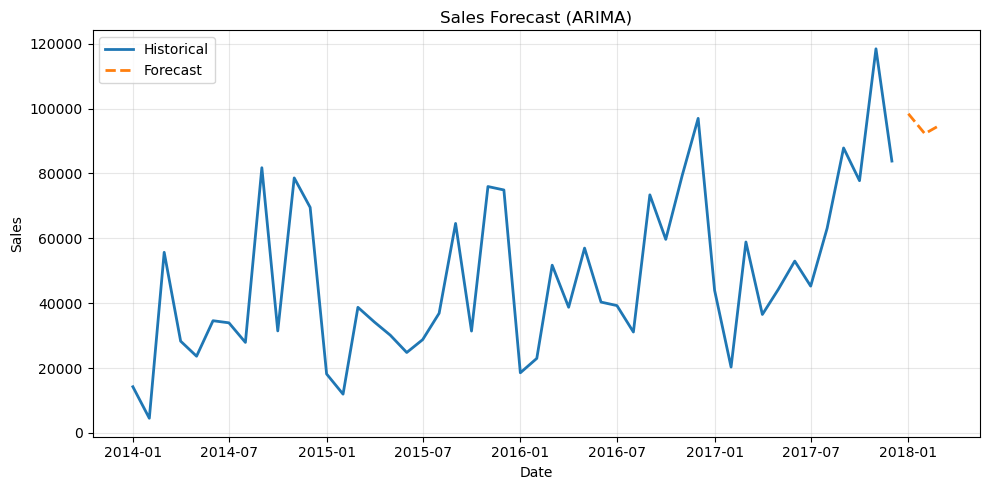

In [40]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import os

# --- Create Monthly Sales (from cleaned df, NOT df_no_outliers) ---
monthly_sales = (
    df.groupby(pd.Grouper(key='order_date', freq='MS'))['sales']
      .sum()
      .reset_index()
)

print("Monthly rows:", monthly_sales.shape)

# --- Prepare Time Series ---
ts = monthly_sales.set_index('order_date')['sales']
ts = ts.asfreq('MS')

print("Time series length:", len(ts))

# --- Fit ARIMA Model ---
model = ARIMA(ts, order=(1,1,0))
model_fit = model.fit()

# --- Forecast Next 3 Months ---
forecast = model_fit.forecast(steps=3)

print("Forecast:\n", forecast)

# --- Save Forecast ---
forecast_df = forecast.reset_index()
forecast_df.columns = ['date', 'forecasted_sales']

os.makedirs("outputs", exist_ok=True)
forecast_df.to_csv("outputs/sales_forecast_next_3_months.csv", index=False)

# --- Plot ---
plt.figure(figsize=(10,5))
plt.plot(ts, label="Historical", linewidth=2)
plt.plot(forecast.index, forecast.values, linestyle='--', label="Forecast", linewidth=2)

plt.title("Sales Forecast (ARIMA)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/sales_forecast.png")
plt.show()